In [4]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

## Part 1 : Stock prices and news

1. View price trends

/var/folders/vj/1dzb5n4d64vd6jbcprcbjkjc0000gn/T/ipykernel_2977/1672139258.py:4: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  prices["Date"] = pd.to_datetime(prices["Date"])


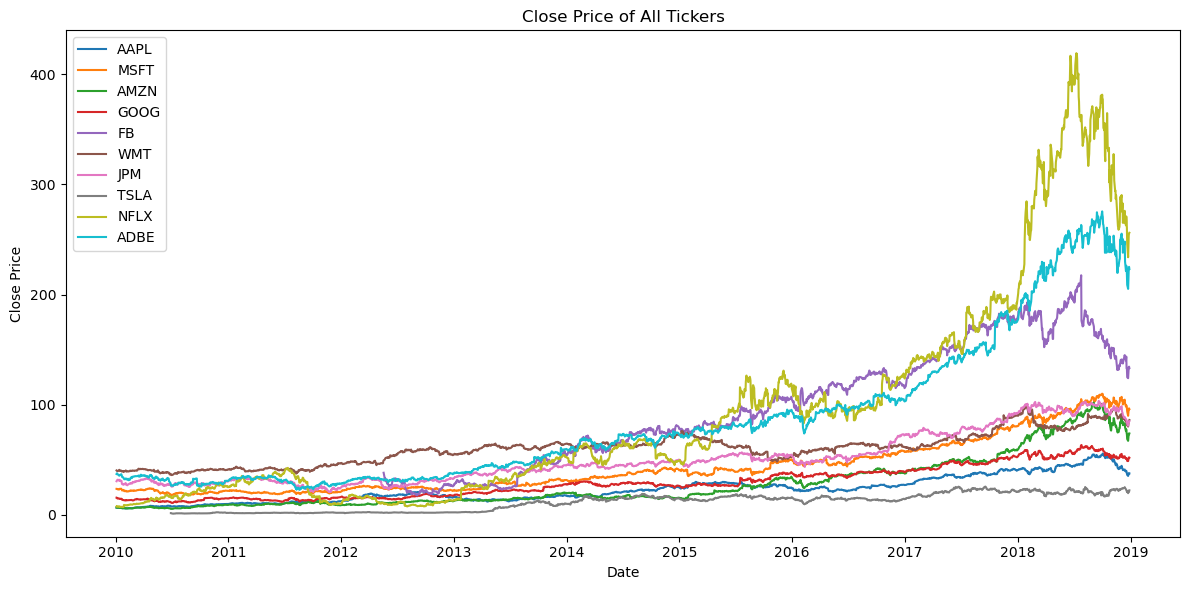

In [5]:
DATA_DIR = Path("../data/")

prices = pd.read_csv(DATA_DIR / 'prices_data.csv')
prices["Date"] = pd.to_datetime(prices["Date"])

tickers = prices["ticker"].unique()
plt.figure(figsize=(12, 6))

for t in tickers:
    sub = prices[prices["ticker"] == t].sort_values("Date")
    plt.plot(sub["Date"], sub["Close"], label=t)

plt.legend()
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("Close Price of All Tickers")
plt.tight_layout()
plt.show()

2. Prepare news data

In [6]:
headlines = pd.read_csv(DATA_DIR / "headlines.csv")

# clean headlines
headlines = headlines.dropna(subset=["ticker", "headline"])
headlines = headlines[headlines["ticker"].str.strip() != ""]
headlines = headlines[headlines["headline"].str.strip() != ""]
headlines["ticker"] = headlines["ticker"].str.strip().str.upper()
headlines["date"] = pd.to_datetime(headlines["date"]).dt.date

headlines.head()

,ticker,headline,date
0,DVA,Davita (NYSE:DVA): EPS of $0.96 beats by $0.01...,2011-05-02
1,CGNX,Cognex (NASDAQ:CGNX): EPS of $0.32 beats by $0...,2011-05-02
2,AEIS,Advanced Energy Industries (NASDAQ:AEIS):,2011-05-02
3,LOCM,Local.com (NASDAQ:LOCM):,2011-05-02
4,CYDEQ,CyberDefender (CYDE):,2011-05-02


3. Calculate CAR

In [7]:
prices["Date"] = pd.to_datetime(prices["Date"],  utc=True)
prices["date"] = prices["Date"].dt.date

# sort by date, calculate daily return
prices = prices.sort_values(["ticker", "Date"])
prices["ret"] = prices.groupby("ticker")["Close"].pct_change()

g = prices.groupby("ticker")["ret"]
prices["ret_m1"] = g.shift(1)    # t-1
prices["ret_p1"] = g.shift(-1)   # t+1

# CAR[-1,+1]
prices["CAR_m1_p1"] = prices["ret_m1"] + prices["ret"] + prices["ret_p1"]

price_cols = ["ticker", "date", "Close", "CAR_m1_p1"]
prices_small = prices[price_cols].copy()

prices_small.head()

,ticker,date,Close,CAR_m1_p1
0,AAPL,2010-01-04,6.505279,NaN
1,AAPL,2010-01-05,6.516527,NaN
2,AAPL,2010-01-06,6.412873,-0.016026
3,AAPL,2010-01-07,6.401018,-0.011107
4,AAPL,2010-01-08,6.443573,-0.004022


4. Merge prices and news

In [14]:
df_all = pd.merge(
    headlines, prices_small, 
    on=["ticker", "date"],
    how="left"
)

df_all = df_all.dropna(subset=["CAR_m1_p1"]).reset_index(drop=True)
df_all = df_all.rename(columns={"CAR_m1_p1": "eventRet"})
df_all.to_csv(DATA_DIR / "combined_car_m1_p1.csv", index=False)
data_df = df_all 

## Part 2: Sentiment Information

1. Load model

In [15]:
import torch, transformers
print("torch:", torch.__version__)
print("transformers:", transformers.__version__)

torch: 2.9.0
transformers: 4.57.3


In [16]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch.nn.functional as F

# FinBERT
model_name = "ProsusAI/finbert"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)
model.to(device)
model.eval()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

2. FinBert Scores

In [17]:
import numpy as np
import torch.nn.functional as F

id2label = model.config.id2label
print(id2label)     
inv_label = {v:k for k,v in id2label.items()}

@torch.no_grad()
def finbert_predict(texts, batch_size=32, max_length=128):
    all_probs = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(device)

        outputs = model(**enc)
        probs = F.softmax(outputs.logits, dim=-1).cpu().numpy()
        all_probs.append(probs)

    return np.vstack(all_probs)


{0: 'positive', 1: 'negative', 2: 'neutral'}


In [18]:
data_df["headline"] = data_df["headline"].astype(str)
texts = data_df["headline"].tolist()

probs = finbert_predict(texts)

neg_idx = inv_label["negative"]
neu_idx = inv_label["neutral"]
pos_idx = inv_label["positive"]

data_df["finbert_neg"] = probs[:, neg_idx]
data_df["finbert_neu"] = probs[:, neu_idx]
data_df["finbert_pos"] = probs[:, pos_idx]

# define finbert_score
data_df["finbert_score"] = data_df["finbert_pos"] - data_df["finbert_neg"]

data_df[["headline", "finbert_pos", "finbert_neg", "finbert_neu", "finbert_score"]].head()

,headline,finbert_pos,finbert_neg,finbert_neu,finbert_score
0,Whole Foods (WFMI) -5.2% following a downgrade...,0.022275,0.940207,0.037519,-0.917932
1,Netflix (NFLX +1.1%) shares post early gains a...,0.951952,0.018521,0.029527,0.933431
2,The likely winners in Microsoft's (MSFT -1.4%)...,0.122482,0.010699,0.866818,0.111783
3,Microsoft (MSFT -1.2%) and Skype signed their ...,0.696708,0.008052,0.295240,0.688656
4,Amazon.com (AMZN -1.7%) shares slip as comment...,0.007746,0.969940,0.022314,-0.962194


3. FinBert vs CAR

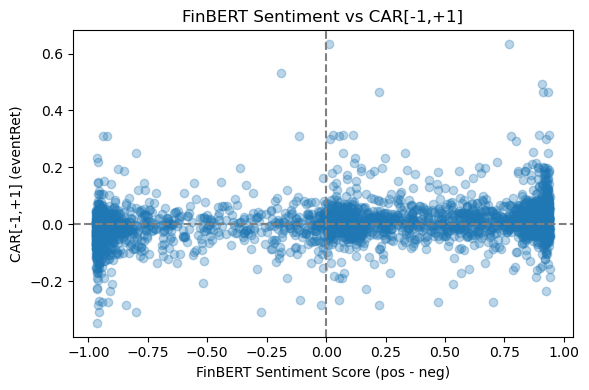

Overall correlation(finbert_score, eventRet): 0.27745608015178713


ticker
AAPL    0.348238
ADBE    0.491204
AMZN    0.176927
FB      0.373122
GOOG    0.253407
JPM     0.391696
MSFT    0.171524
NFLX    0.321230
TSLA    0.315724
WMT     0.364015
Name: eventRet, dtype: float64

In [19]:
plt.figure(figsize=(6, 4))
plt.scatter(data_df["finbert_score"], data_df["eventRet"], alpha=0.3)
plt.axhline(0, color="grey", linestyle="--")
plt.axvline(0, color="grey", linestyle="--")
plt.xlabel("FinBERT Sentiment Score (pos - neg)")
plt.ylabel("CAR[-1,+1] (eventRet)")
plt.title("FinBERT Sentiment vs CAR[-1,+1]")
plt.tight_layout()
plt.show()

# overall corr
corr_finbert = data_df["finbert_score"].corr(data_df["eventRet"])
print("Overall correlation(finbert_score, eventRet):", corr_finbert)

# corr. by ticker
corr_by_ticker_finbert = (
    data_df.groupby("ticker")[["finbert_score", "eventRet"]]
           .corr()
           .unstack()
)
corr_by_ticker_finbert = corr_by_ticker_finbert["finbert_score"]["eventRet"]
corr_by_ticker_finbert

## Part 3: Add label

1. Use Percentage

In [20]:
import re

df = data_df.copy()
df["senti_label"] = np.nan  

def label_from_pct(text):
    if not isinstance(text, str):
        return np.nan
    m = re.search(r'([+-]?\d+(\.\d+)?)\s*%', text)
    if not m:
        return np.nan
    val = float(m.group(1))
    # rule：% >0 positive，<0 negative
    if val > 0:
        return 1
    elif val < 0:
        return 0
    else:
        return np.nan

df["senti_label"] = df["headline"].apply(label_from_pct)

2. Beats / Misses

In [21]:
mask_beats = df["headline"].str.contains("beats", case=False, na=False)
mask_misses = df["headline"].str.contains("misses", case=False, na=False)

df.loc[mask_beats, "senti_label"] = 1
df.loc[mask_misses, "senti_label"] = 0

3. Finbert scores

In [22]:
# finbert_score > +threshold, label 1
thr = 0.2  

mask_nan = df["senti_label"].isna()
conf_score = df.loc[mask_nan, "finbert_score"]

df.loc[mask_nan & (conf_score >  thr), "senti_label"] = 1
df.loc[mask_nan & (conf_score < -thr), "senti_label"] = 0

# throw |score| <= thr samples
mask_low_conf = mask_nan & (conf_score.abs() <= thr)
df_weak = df[mask_low_conf].copy()
df_strong = df[~df["senti_label"].isna()].copy()

print("Total samples:", len(df))
print("Strong samples:", len(df_strong))
print("Week samples:", len(df_weak))


Total samples: 2749
Strong samples: 2496
Week samples: 253


In [23]:
df_strong["senti_label"] = df_strong["senti_label"].astype(int) # convert senti_label to 0/1
ldf = df_strong[["ticker", "headline", "date", "eventRet", "senti_label"]].reset_index(drop=True)

## Part 4: Baseline model

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [45]:
ldf = df_strong[["ticker", "headline", "date", "eventRet", "senti_label"]].copy()
ldf = ldf.reset_index(drop=True)
ldf.rename(columns={"senti_label": "label"}, inplace=True)

print(ldf.head())
print(ldf["label"].value_counts())
ldf.to_csv(DATA_DIR / "sentiment_labeled_headlines.csv", index=False)

  ticker                                           headline        date  \
0   AMZN  Whole Foods (WFMI) -5.2% following a downgrade...  2011-05-02   
1   NFLX  Netflix (NFLX +1.1%) shares post early gains a...  2011-05-02   
2   MSFT  The likely winners in Microsoft's (MSFT -1.4%)...  2011-05-10   
3   MSFT  Microsoft (MSFT -1.2%) and Skype signed their ...  2011-05-10   
4   AMZN  Amazon.com (AMZN -1.7%) shares slip as comment...  2011-05-12   

   eventRet  label  
0  0.017650      0  
1 -0.012912      1  
2 -0.019817      0  
3 -0.019817      0  
4 -0.006607      0  
label
1    1677
0     819
Name: count, dtype: int64


In [46]:
# 1) Prepare X, y
X = ldf["headline"].astype(str)
y = ldf["label"].astype(int)

# 2) Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.1,
    random_state=42,
    stratify=y
)

# 3) Headlines -> TF-IDF vectors
tfidf = TfidfVectorizer(
    max_features=20000,   
    ngram_range=(1, 2),   # uni-gram + bi-gram
    min_df=2
)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec  = tfidf.transform(X_test)

In [53]:
models = [
    ("LR", LogisticRegression(
        max_iter=1000,
        n_jobs=1,
        class_weight="balanced"   
    )),
    ("KNN", KNeighborsClassifier(
        n_neighbors=5,            # k = 5
        n_jobs=1
    )),
    ("CART", DecisionTreeClassifier(
        max_depth=None,           
        random_state=42,
        class_weight="balanced"
    )),
]

results = []
for name, clf in models:
    print("=" * 50)
    print(f"Model: {name}")
    clf.fit(X_train_vec, y_train)
    y_pred = clf.predict(X_test_vec)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred, digits=4))

    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    f1_macro = report["macro avg"]["f1-score"]
    results.append({
        "model": name,
        "accuracy": acc,
        "f1_macro": f1_macro
    })

results_df = pd.DataFrame(results)
results_df

Model: LR
Accuracy: 0.716
Confusion matrix:
 [[ 47  35]
 [ 36 132]]
              precision    recall  f1-score   support

           0     0.5663    0.5732    0.5697        82
           1     0.7904    0.7857    0.7881       168

    accuracy                         0.7160       250
   macro avg     0.6783    0.6794    0.6789       250
weighted avg     0.7169    0.7160    0.7164       250

Model: KNN
Accuracy: 0.708
Confusion matrix:
 [[ 31  51]
 [ 22 146]]
              precision    recall  f1-score   support

           0     0.5849    0.3780    0.4593        82
           1     0.7411    0.8690    0.8000       168

    accuracy                         0.7080       250
   macro avg     0.6630    0.6235    0.6296       250
weighted avg     0.6899    0.7080    0.6882       250

Model: CART
Accuracy: 0.604
Confusion matrix:
 [[ 29  53]
 [ 46 122]]
              precision    recall  f1-score   support

           0     0.3867    0.3537    0.3694        82
           1     0.6971    0.7

,model,accuracy,f1_macro
0,LR,0.716,0.678878
1,KNN,0.708,0.629630
2,CART,0.604,0.540399


## Part 4: Expert labels

1. Prepare expert labels

In [50]:
expert_path = DATA_DIR / "newsdata_labelled_v3.csv"
expert = pd.read_csv(expert_path, encoding="ISO-8859-1")

# headline + label(0/1)
expert = expert.rename(columns={"headline": "headline", "sentiment": "label"})
expert = expert.dropna(subset=["headline", "label"])
expert["label"] = expert["label"].astype(int)

print(expert.head())
print(expert["label"].value_counts())

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X_e = expert["headline"].astype(str)
y_e = expert["label"].astype(int)

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_e, y_e,
    test_size=0.1,
    random_state=42,
    stratify=y_e
)

tfidf_e = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_vec_e = tfidf_e.fit_transform(X_train_e)
X_test_vec_e  = tfidf_e.transform(X_test_e)

         datetime                                           headline ticker  \
0  1/16/2020 5:25  $MMM fell on hard times but could be set to re...    MMM   
1  1/11/2020 6:43  Wolfe Research Upgrades 3M $MMM to ¡§Peer Perf...    MMM   
2   1/9/2020 9:37  3M $MMM Upgraded to ¡§Peer Perform¡¨ by Wolfe ...    MMM   
3  1/8/2020 17:01  $MMM #insideday follow up as it also opened up...    MMM   
4   1/8/2020 7:44  $MMM is best #dividend #stock out there and do...    MMM   

   label  
0      0  
1      1  
2      1  
3      1  
4      0  
label
1    5482
0    3988
Name: count, dtype: int64


2. Run models on expert data

In [56]:
models_e = [
    ("LR", LogisticRegression(
        max_iter=1000,
        n_jobs=1,
        class_weight="balanced"
    )),
    ("KNN", KNeighborsClassifier(
        n_neighbors=5,
        n_jobs=1
    )),
    ("CART", DecisionTreeClassifier(
        max_depth=None,
        random_state=42,
        class_weight="balanced"
    )),
]

results_expert = []

for name, clf in models_e:
    print("=" * 50)
    print(f"[Expert] Model: {name}")
    
    clf.fit(X_train_vec_e, y_train_e)
    y_pred_e = clf.predict(X_test_vec_e)

    acc = accuracy_score(y_test_e, y_pred_e)
    print("Accuracy:", acc)
    print("Confusion matrix:\n", confusion_matrix(y_test_e, y_pred_e))
    print(classification_report(y_test_e, y_pred_e, digits=4))

    report = classification_report(y_test_e, y_pred_e, output_dict=True)
    f1_macro = report["macro avg"]["f1-score"]

    results_expert.append({
        "dataset": "expert",
        "model": name,
        "accuracy": acc,
        "f1_macro": f1_macro
    })

results_expert_df = pd.DataFrame(results_expert)
results_expert_df

[Expert] Model: LR
Accuracy: 0.9778247096092925
Confusion matrix:
 [[390   9]
 [ 12 536]]
              precision    recall  f1-score   support

           0     0.9701    0.9774    0.9738       399
           1     0.9835    0.9781    0.9808       548

    accuracy                         0.9778       947
   macro avg     0.9768    0.9778    0.9773       947
weighted avg     0.9779    0.9778    0.9778       947

[Expert] Model: KNN
Accuracy: 0.8753959873284055
Confusion matrix:
 [[338  61]
 [ 57 491]]
              precision    recall  f1-score   support

           0     0.8557    0.8471    0.8514       399
           1     0.8895    0.8960    0.8927       548

    accuracy                         0.8754       947
   macro avg     0.8726    0.8716    0.8721       947
weighted avg     0.8753    0.8754    0.8753       947

[Expert] Model: CART
Accuracy: 0.9831045406546991
Confusion matrix:
 [[394   5]
 [ 11 537]]
              precision    recall  f1-score   support

           0     0

,dataset,model,accuracy,f1_macro
0,expert,LR,0.977825,0.977285
1,expert,KNN,0.875396,0.872056
2,expert,CART,0.983105,0.982710


3. Compare with self labels

In [57]:
results_self_df = pd.DataFrame(results_df) 
results_self_df["dataset"] = "self"

results_self_df_reordered = results_self_df[["dataset", "model", "accuracy", "f1_macro"]]

all_results = pd.concat(
    [results_self_df_reordered, results_expert_df],
    ignore_index=True
)

all_results

,dataset,model,accuracy,f1_macro
0,self,LR,0.716000,0.678878
1,self,KNN,0.708000,0.629630
2,self,CART,0.604000,0.540399
3,expert,LR,0.977825,0.977285
4,expert,KNN,0.875396,0.872056
5,expert,CART,0.983105,0.982710
